In [1]:
import logging
from pathlib import Path
from huggingface_hub import login
import os
from PIL import Image
import torch
from torchvision.transforms.functional import to_tensor
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from functools import partial
from tqdm.auto import tqdm
import cv2 as cv
from itertools import chain
from scipy.ndimage import binary_fill_holes

logging.disable(logging.WARNING)

torch.manual_seed(1)

from google.colab import userdata
os.environ["huggingface"] = userdata.get("huggingface")
if not (Path.home()/'.cache/huggingface'/'token').exists(): login(os.environ["huggingface"])

# Set device
torch_device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
if "mps" == torch_device: os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = "1"

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [2]:
def match_list_size(l1, l2, fill_with=None):
    if len(l1) > len(l2):
        extend_list = l2
    elif len(l2) > len(l1):
        extend_list = l1
    else:
        return

    extend_list.extend([fill_with]*(abs(len(l1) - len(l2))))

def items_to_grid(items, col_count, ax_func, titles=None, screen_width=26):
    titles = titles or []
    items_iter = iter(items)
    row_count = ceil(len(items)/col_count)
    plt.rcParams['figure.figsize'] = [screen_width, (screen_width/col_count)*row_count]
    f, axarr = plt.subplots(row_count, col_count)
    curr_row = 0

    try:
        flat_axs = list(chain.from_iterable(axarr))
    except:
        flat_axs = axarr
    match_list_size(flat_axs, titles)

    for ax, title in zip(flat_axs, titles):
        if (item := next(items_iter, None)) is not None:
            ax_func(item, ax)
        else:
            ax.axis('off')
        if title:
            ax.set_title(title)

    plt.subplots_adjust(wspace=.05, hspace=.05)

def images_to_grid(images, col_count, *args, **kwargs):
    def ax_func(img, ax):
        ax.imshow(img)
        ax.axis('off')
    items_to_grid(images, col_count, ax_func, *args, **kwargs)

def latents_to_grid_bw(latents, col_count, *args, **kwargs):
    def ax_func(img, ax):
        ax.imshow(img, cmap="gray")
        ax.axis('off')
    items_to_grid(latents, col_count, ax_func, *args, **kwargs)

def masks_to_grid(original_image, masks, col_count, *args, **kwargs):
    ax_func = partial(plot_mask, original_image)
    items_to_grid(masks, col_count, ax_func, *args, **kwargs)

In [3]:
def encode(image):
    with torch.no_grad():
        img_tensor = to_tensor(image)
        img_tensor = img_tensor[:3]
        img_tensor =  (img_tensor * 2 - 1).clamp(-1, 1)
        img_tensor.unsqueeze_(0)

        latent = vae.encode(img_tensor.to("cuda").half())
        latent = 0.18215 * latent.latent_dist.sample()
    return latent

In [4]:
# Function which can convert latents back into an image
def to_image(latents):
    with torch.no_grad():
        image = vae.decode(1 / 0.18215 * latents).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image[0].detach().cpu().permute(1, 2, 0).numpy()
        image = (image * 255).round().astype("uint8")
        return Image.fromarray(image)

In [5]:
def show_arr(np_arr):
    with torch.no_grad():
        image = (np_arr / 2 + 0.5).clamp(0, 1)
        image = image[0].detach().cpu().numpy()
        image = (image * 255).round().astype("uint8")
        return Image.fromarray(image)

In [6]:
def plot_mask(original_image, mask, ax=plt):
    mask_scaled = np.array(Image.fromarray(mask).resize((512,512), resample=Image.BOX))
    ax.imshow(np.array(original_image), cmap='gray')
    ax.imshow(
        abs(mask_scaled-1),
        cmap='binary',
        alpha=0.5*(mask_scaled > 0.5).astype(float)
    )
    ax.axis('off')
    return ax

In [7]:
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=torch.float16).to("cuda")
unet = UNet2DConditionModel.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="unet", torch_dtype=torch.float16).to("cuda")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14", torch_dtype=torch.float16)
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14", torch_dtype=torch.float16).to("cuda")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet%2Fconfig.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

In [228]:
original_prompt = "Strawberries"
new_prompt = "Oranges"

In [229]:
from fastdownload import FastDownload

In [230]:
height = 512
width = 512
img_path = FastDownload().download('https://raw.githubusercontent.com/johnrobinsn/diffusion_experiments/main/images/bowloberries_scaled.jpg')
original_image = Image.open(img_path).resize((height, width))

batch_size = 1

torch.manual_seed(99);

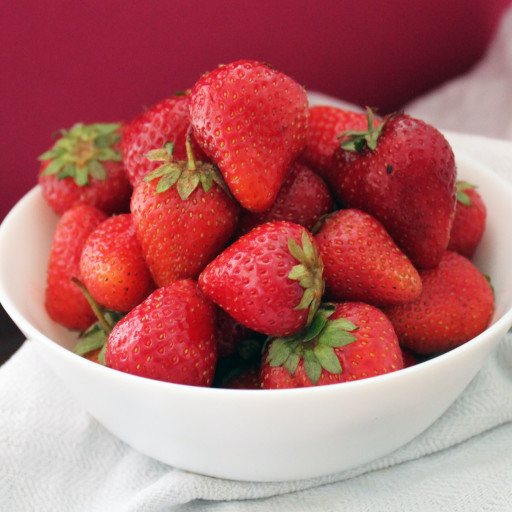

In [231]:
original_image

In [232]:
original_image_latents = encode(original_image)

In [233]:
original_image_latents.shape

torch.Size([1, 4, 64, 64])

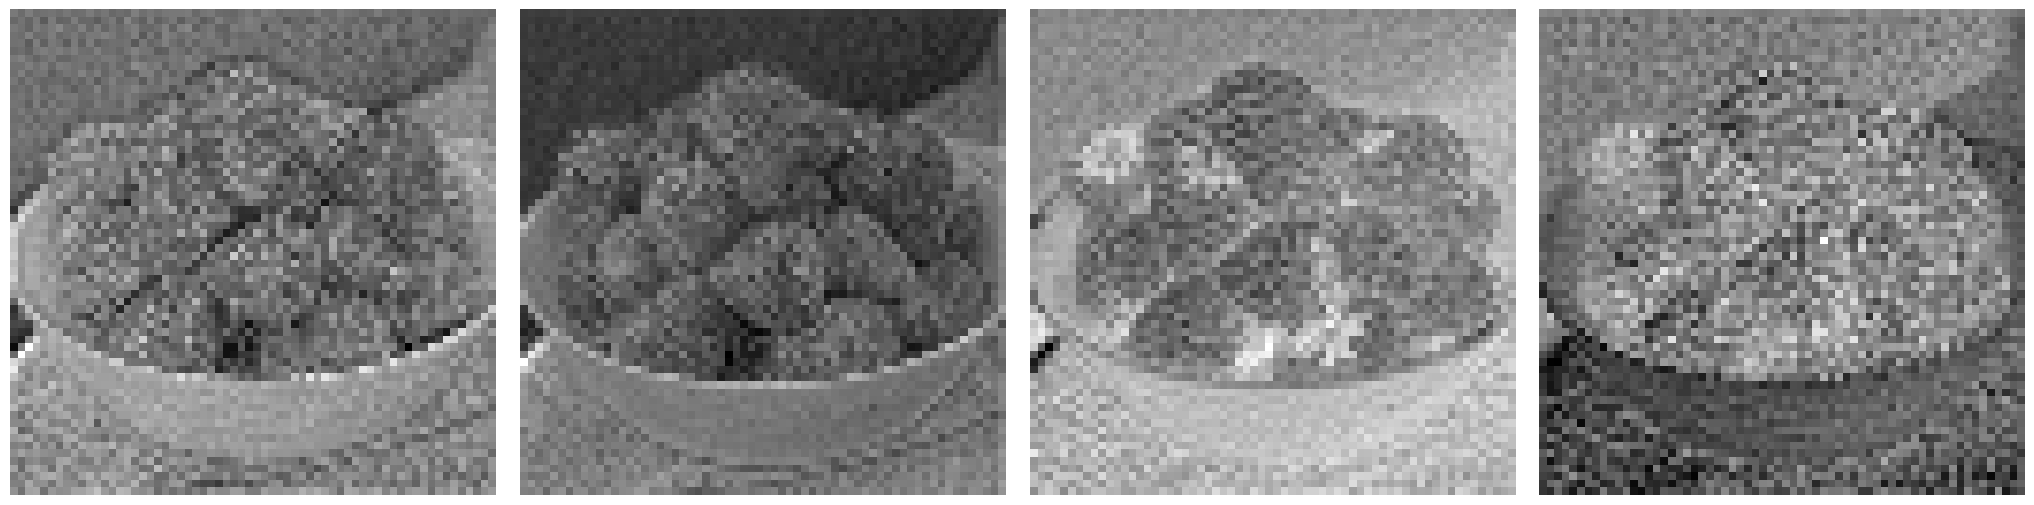

In [234]:
latents_to_grid_bw(original_image_latents.squeeze().detach().cpu(), 4)

In [235]:
def create_text_embeddings(prompts, batch_size=1):
    text_embeddings = []
    for prompt in prompts:
        text_input = tokenizer([prompt], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
        text_embeddings += text_encoder(text_input.input_ids.to("cuda"))[0].half().unsqueeze(0)

    # create matching unconditional input
    max_length = text_input.input_ids.shape[-1]
    uncond_input = tokenizer([""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt")
    uncond_embeddings = text_encoder(uncond_input.input_ids.to("cuda"))[0].half()

    return torch.cat([uncond_embeddings, *text_embeddings])

In [236]:
tokenizer(["strawberries"], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")

{'input_ids': tensor([[49406, 17796, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0]])}

In [237]:
prompts = [original_prompt, new_prompt]
combined_embeddings = create_text_embeddings(prompts)

In [238]:
scheduler_config = {
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "num_train_timesteps": 1000,
  "set_alpha_to_one": False,
  "steps_offset": 1,
  "trained_betas": None,
  "clip_sample": False
}

In [239]:
def init_scheduler(num_inference_steps):
    scheduler = DDIMScheduler(**scheduler_config)
    scheduler.set_timesteps(num_inference_steps)
    return scheduler

In [240]:
num_inference_steps = 50
scheduler = init_scheduler(num_inference_steps)

In [241]:
def create_noise(noise_scheduler, initial_latents, height=512, width=512, batch_size=1, start_step=10, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    # print("in_channels", unet.config.in_channels)
    initial_noise = torch.randn((batch_size, unet.config.in_channels, height // 8, width // 8)).to("cuda").half()

    if start_step > 0:
        return noise_scheduler.add_noise(
            initial_latents,
            initial_noise,
            timesteps=torch.tensor([noise_scheduler.timesteps[start_step]])
        )
    return initial_noise * noise_scheduler.init_noise_sigma

In [242]:
mask_noise_step = num_inference_steps//2
noisy_latents = create_noise(scheduler, original_image_latents, start_step=mask_noise_step)

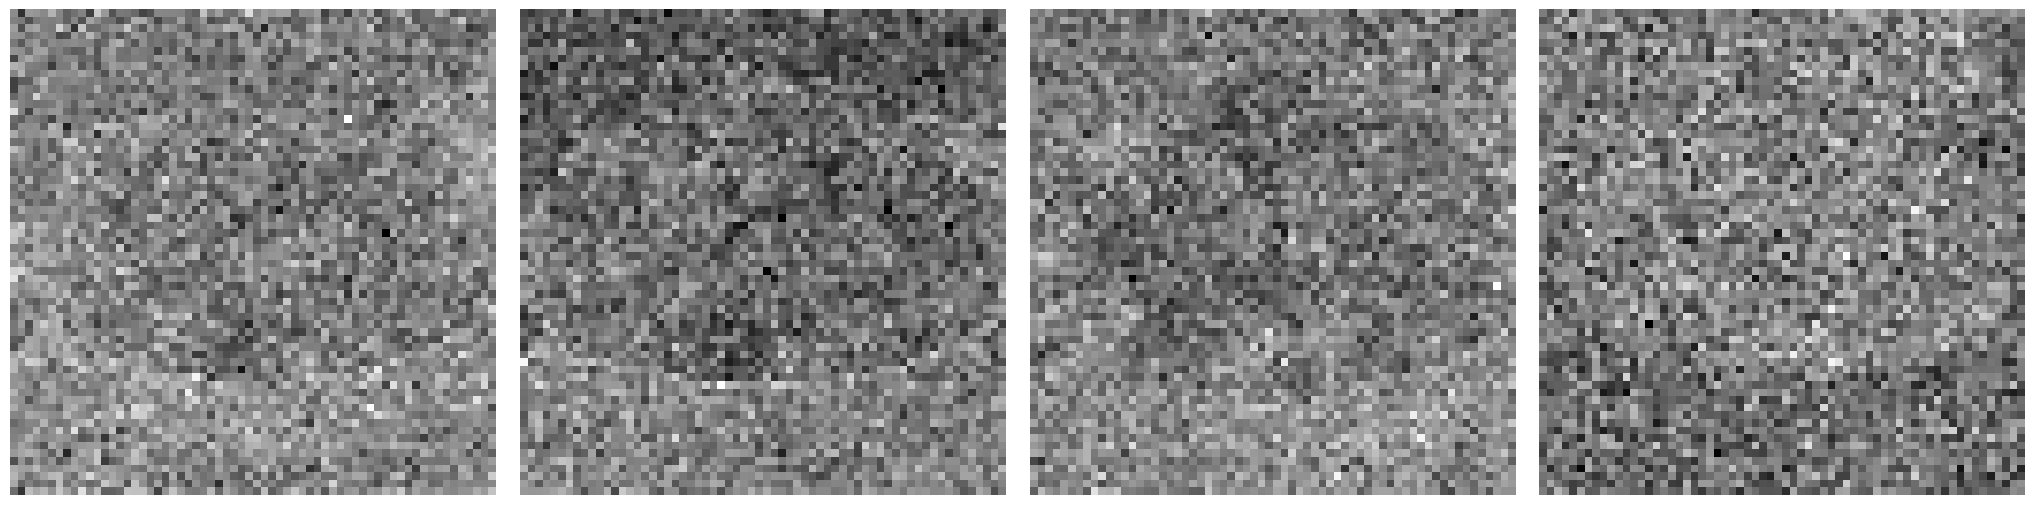

In [243]:
latents_to_grid_bw(noisy_latents.squeeze().detach().cpu(), 4)

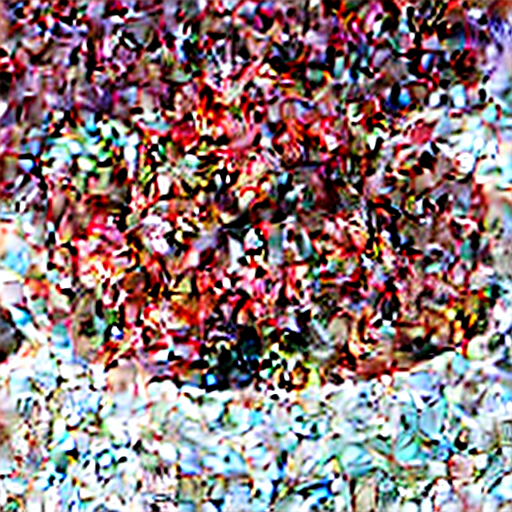

In [244]:
to_image(noisy_latents)

In [245]:
guidance_scale = 7.5

In [246]:
def predict_noise(scheduler, latents, combined_embeddings, guidance_scale, timestep, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    input = torch.cat([latents] * combined_embeddings.shape[0])
    input = scheduler.scale_model_input(input, timestep)

    # predict the noise residual
    with torch.no_grad():
        pred = unet(input, timestep, encoder_hidden_states=combined_embeddings).sample

    # perform guidance
    pred_uncond, pred_text_original, pred_text_new = pred.chunk(3)

    pred_original = pred_uncond + guidance_scale * (pred_text_original - pred_uncond)
    pred_new = pred_uncond + guidance_scale * (pred_text_new - pred_uncond)

    return pred_original, pred_new

In [247]:
n = 10

In [248]:
with torch.no_grad():
    all_preds_base = torch.zeros_like(original_image_latents)
    original_preds_base = torch.zeros_like(original_image_latents)
    new_preds_base = torch.zeros_like(original_image_latents)
    for i in range(n):
        seed=i*3
        noise = create_noise(scheduler, original_image_latents, start_step=25, seed=seed)
        original_preds, new_preds = predict_noise(scheduler,
                                                  noise,
                                                  combined_embeddings,
                                                  guidance_scale,
                                                  scheduler.timesteps[mask_noise_step],
                                                  seed=seed)
        original_preds_base += original_preds
        new_preds_base += new_preds
        all_preds_base += (new_preds - original_preds).abs()
    all_preds_base /= n
    original_preds_base /= n
    new_preds_base/= n

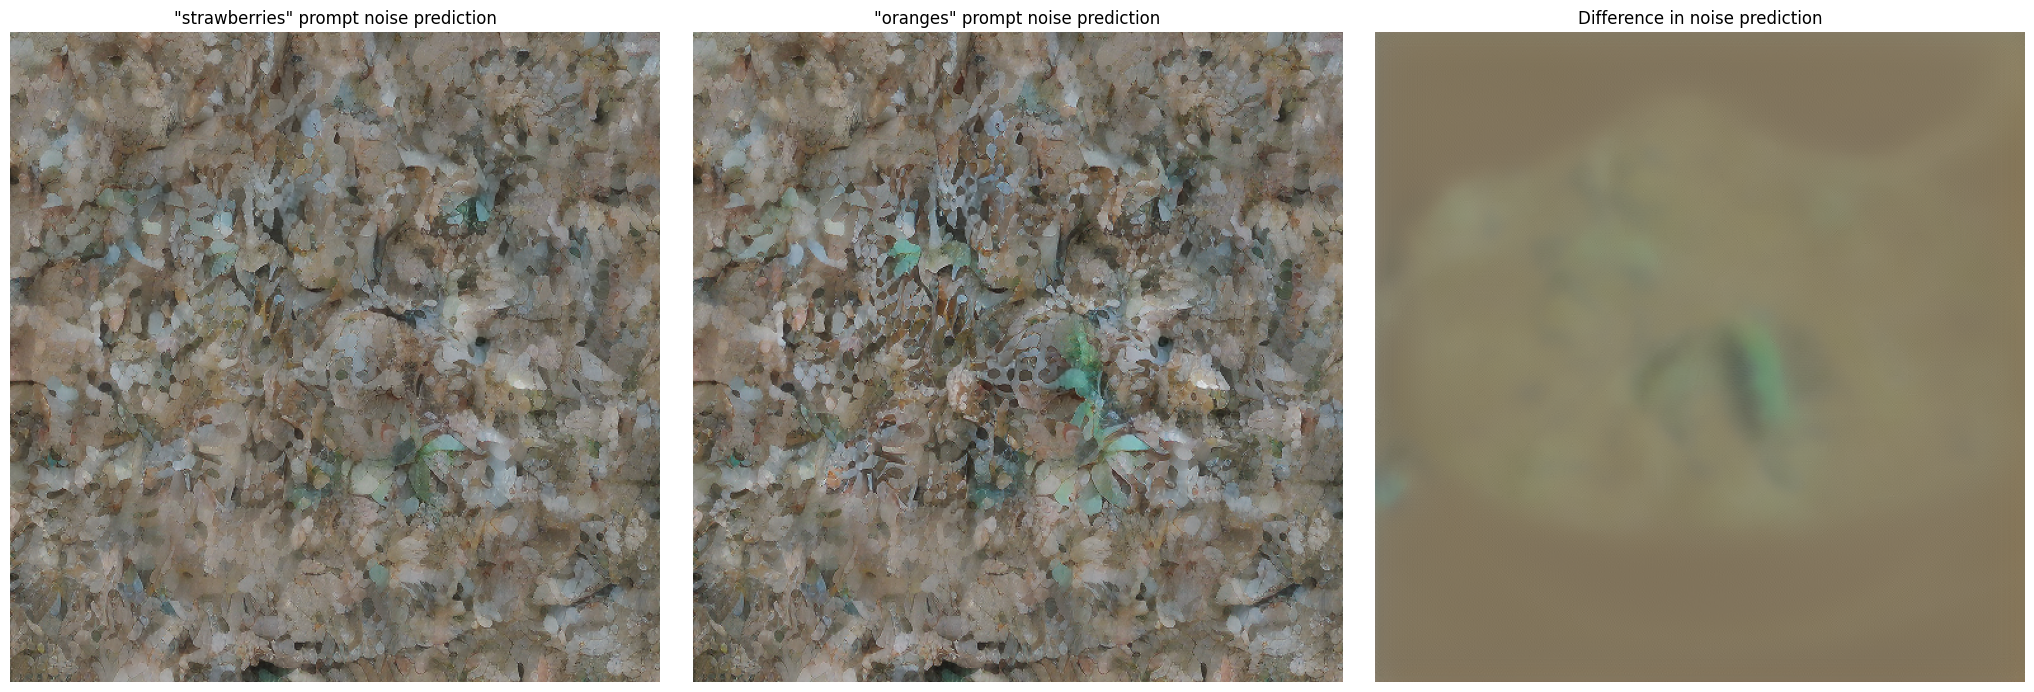

In [249]:
images_to_grid([to_image(original_preds_base), to_image(new_preds_base), to_image(all_preds_base)], 3, titles=['"strawberries" prompt noise prediction', '"oranges" prompt noise prediction', "Difference in noise prediction"])

In [250]:
all_preds_base.shape

torch.Size([1, 4, 64, 64])

In [251]:
all_preds = all_preds_base.mean(axis=1)

all_preds = all_preds - all_preds.min()
all_preds = all_preds / all_preds.max()

In [252]:
all_preds.min(), all_preds.max()

(tensor(0., device='cuda:0', dtype=torch.float16),
 tensor(1., device='cuda:0', dtype=torch.float16))

In [253]:
all_preds = all_preds.squeeze().detach().cpu().numpy()

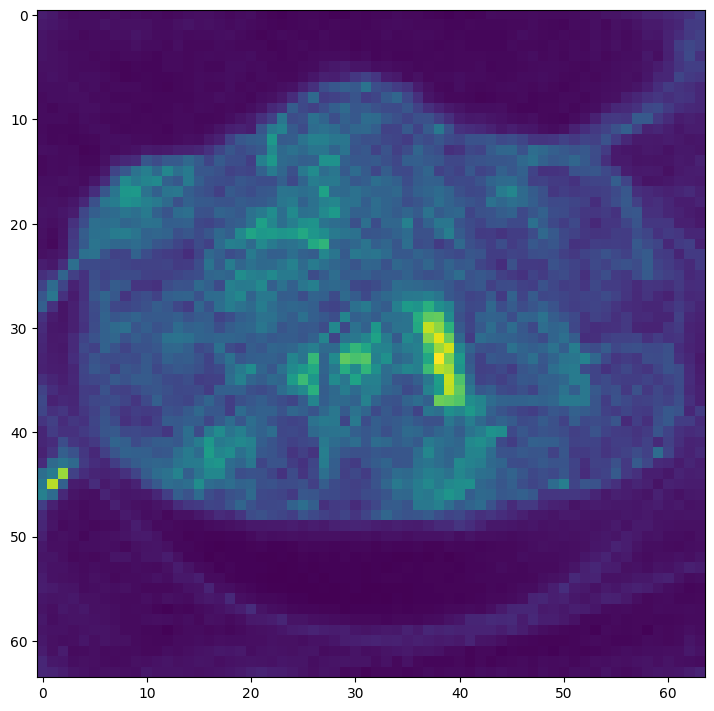

In [254]:
plt.imshow(all_preds)

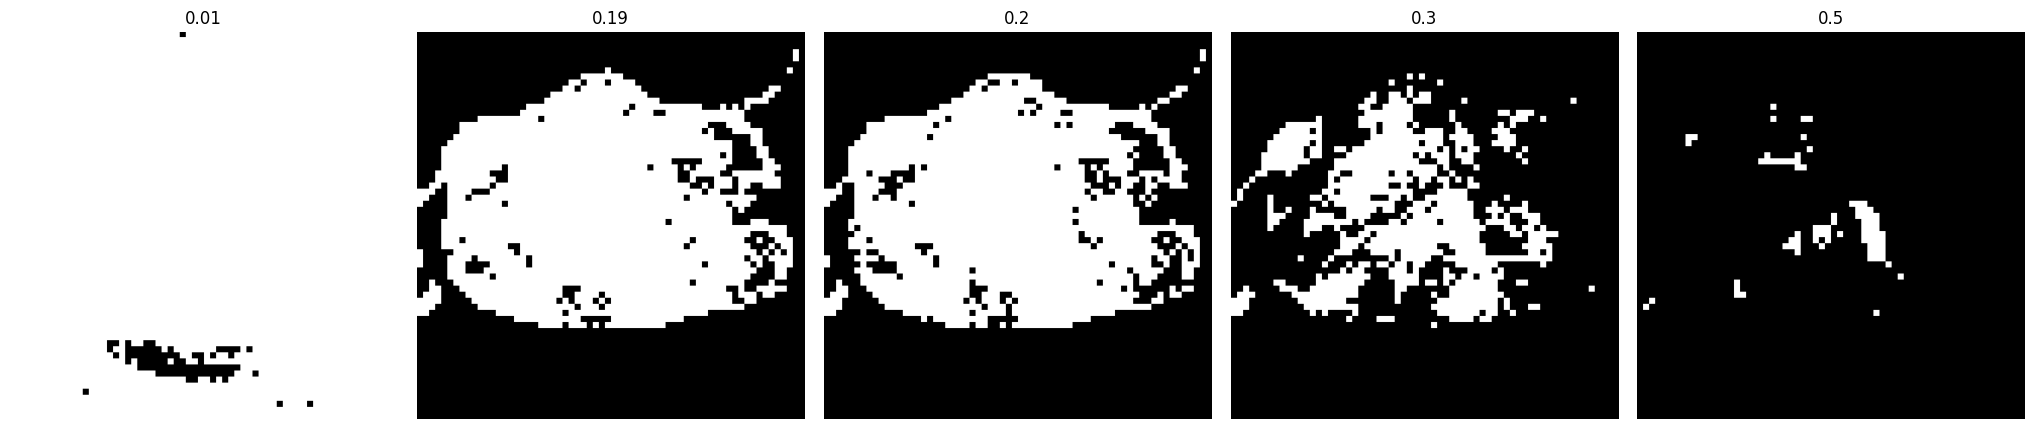

In [290]:
possible_thresholds = [0.01, 0.19, 0.2, 0.3, 0.5]
masks = [(all_preds > threshold) for threshold in possible_thresholds]
masks_to_grid(original_image, masks, len(possible_thresholds), titles=possible_thresholds)

In [304]:
# set the best threshold value
initial_mask = (all_preds > 0.18).astype(float)

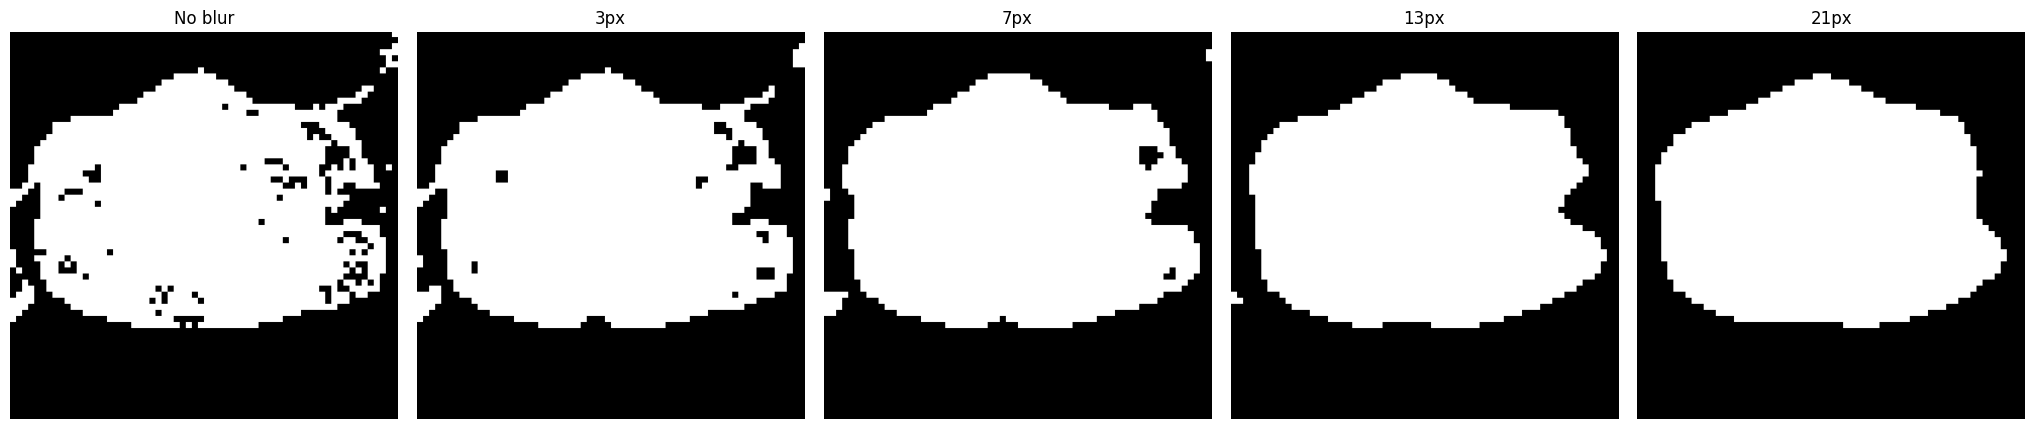

In [305]:
possible_blurs = [3, 7, 13, 21]
titles = [f"{i}px" for i in possible_blurs]

masks = [cv.GaussianBlur(np.array(initial_mask, dtype=np.uint8), (blur_px, blur_px), 0.) for blur_px in possible_blurs]
masks_to_grid(original_image, [initial_mask, *masks], len(possible_blurs) + 1, titles=["No blur", *titles])

In [306]:
mask_np = (cv.GaussianBlur(np.array(initial_mask, dtype=np.uint8), (21, 21), 0.) > 0.1).astype(float)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

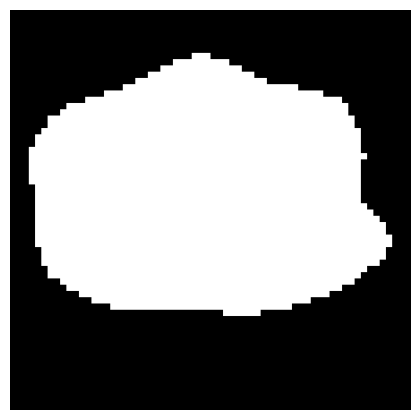

In [307]:
plot_mask(original_image, mask_np)

In [308]:
# set how much of the initial image should be replaced by noise at the start
noise_strength = 0.75
# set a manual seed to ensure that we get consistent results
torch.manual_seed(3)

# create schedulers
denoising_scheduler = init_scheduler(num_inference_steps)
original_image_scheduler = init_scheduler(num_inference_steps)

# store step information
total_steps = len(scheduler.timesteps)
start_step = int(len(scheduler.timesteps)-(num_inference_steps*noise_strength))

# set up callback to see denoising process
intermediate_latents = []
callback = (lambda latents: intermediate_latents.append(latents))

# create text embeddings for new_prompt "zebra"
text_embeddings = create_text_embeddings([new_prompt])

mask = torch.from_numpy(mask_np).type(torch.half).to("cuda")

In [309]:
# create initial noisy latents
noisy_latents = create_noise(denoising_scheduler, original_image_latents, start_step=start_step)

In [310]:
# noisy_latents = mask*yt+((1-mask)*xt)

In [311]:
# denoising loop
for i, t in enumerate(tqdm(denoising_scheduler.timesteps[start_step:])):
    current_step = i + start_step
    next_step = current_step + 1

    input = torch.cat([noisy_latents] * 2)
    scaled_input = denoising_scheduler.scale_model_input(input, t)

    # predict the noise residual
    with torch.no_grad():
        pred = unet(scaled_input, t, encoder_hidden_states=text_embeddings).sample

    # perform guidance
    pred_uncond, pred_text = pred.chunk(2)
    pred_nonscaled = pred_uncond + guidance_scale * (pred_text - pred_uncond)
    pred = pred_nonscaled

    # compute the "previous" noisy sample
    if (next_step < num_inference_steps):
        xt = create_noise(original_image_scheduler, original_image_latents, start_step=next_step)
    else:
        xt = original_image_latents

    yt = denoising_scheduler.step(pred, t, noisy_latents).prev_sample

    noisy_latents = mask*yt+((1-mask)*xt)

    if callback:
        callback(noisy_latents)
final_latents = noisy_latents

  0%|          | 0/38 [00:00<?, ?it/s]

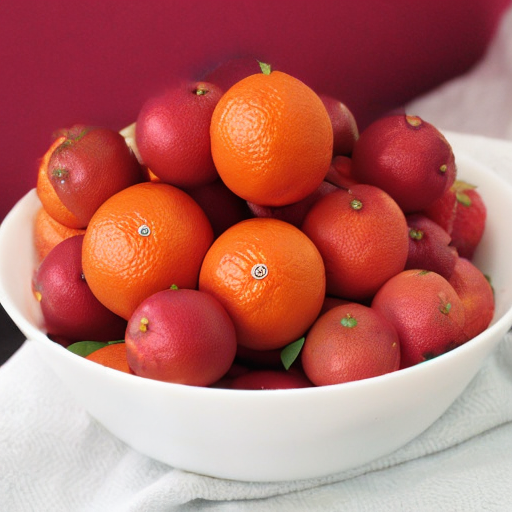

In [312]:
to_image(final_latents)